In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import drive
from pathlib import Path
import hashlib
import os

## **CARGA Y UNIFICACION DE DATOS**

1. **MEDICAMENTOS**

In [2]:
# Cargar y unificar archivos desde Drive AM Medicamentos

# Cargar de archivos desde ruta definida

drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AM')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

# Unir archivos

if df_list:
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")
    df_final_AM = df_final[df_final['nit'] == 800058016].copy()
    df_final_AM['numdocumentoidentificacion'] = (df_final_AM['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final / "archivo_AM.csv"
    df_final_AM.to_csv(output_path, index=False, sep='|')

    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AM)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AM.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Mounted at /content/drive
Leído exitosamente: RIPS_CapitayPGP_AM_json_mes_10-2025.csv | Filas: 2126970 | Columnas: 32
Leído exitosamente: RIPS_CapitayPGP_AM_json_mesactual_11-2025.csv | Filas: 1147615 | Columnas: 32
Proceso Completado
Total de registros encontrados: 764428
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AM.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,m_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,m_cantidadmedicamento,m_diastratamiento,m_vrunitmedicamento,m_vrservicio,m_conceptorecaudo,m_valorpagomoderador,m_consecutivo,m_numfevpagomoderador,codigo_estado_rips_cargas,estado_rips_cargas
286600,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217824,METROSALUD,NI,800058016,FS14208,PT,78dcdb9b9198,...,10.0,1,0.0,0.0,2,4700.0,1,785278,5,Sin información
286601,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217831,METROSALUD,NI,800058016,FS14208,CC,6a1840fea24c,...,21.0,1,0.0,0.0,2,3186.0,1,752068,5,Sin información
286602,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217831,METROSALUD,NI,800058016,FS14208,CC,6a1840fea24c,...,2.0,1,0.0,0.0,2,1514.0,2,752068,5,Sin información
286603,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217865,METROSALUD,NI,800058016,FS14208,CC,96b8e4e0df2d,...,30.0,1,0.0,0.0,5,0.0,1,765387,5,Sin información
286604,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217865,METROSALUD,NI,800058016,FS14208,CC,96b8e4e0df2d,...,60.0,1,0.0,0.0,5,0.0,2,765387,5,Sin información


**2. MAESTRA TARIFAS**

In [10]:
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS')
root
df_tarifas=pd.read_csv(root/"maestra_tarifas.csv",sep="|")
df_tarifas.columns = df_tarifas.columns.str.lower().str.strip()
print(df_tarifas.dtypes)
print(df_tarifas.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
codigo_tecnologia    object
descripcion          object
tarifa                int64
servicio             object
dtype: object
  codigo_tecnologia                             descripcion  tarifa  \
0           32187-6  ACETAMINOFEN 100 MG TABLETA MASTICABLE    1088   
1           32187-5  ACETAMINOFEN 100 MG TABLETA MASTICABLE    1088   
2           32187-4  ACETAMINOFEN 100 MG TABLETA MASTICABLE    1088   
3           32187-3  ACETAMINOFEN 100 MG TABLETA MASTICABLE    1088   
4           32187-2  ACETAMINOFEN 100 MG TABLETA MASTICABLE    1088   

       servicio  
0  Medicamentos  
1  Medicamentos  
2  Medicamentos  
3  Medicamentos  
4  Medicamentos  


**3. POBLACION**

In [11]:
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS')
root
df_poblacion=pd.read_csv(root/"poblacion.csv",sep="|")
df_poblacion.columns = df_poblacion.columns.str.lower().str.strip()
df_poblacion['mes'] = pd.to_datetime(df_poblacion['mes'], errors='coerce')
df_poblacion['mes'] = (df_poblacion['mes'].dt.to_period('M'))
print(df_poblacion.dtypes)
print(df_poblacion.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ips                          object
nit                           int64
municipio                    object
poblacion_afiliada            int64
mes                       period[M]
valor_nota_medicamento        int64
dtype: object
          ips        nit municipio  poblacion_afiliada      mes  \
0  METROSALUD  800058016  Medellin              514867  2025-01   
1  METROSALUD  800058016  Medellin              491296  2025-02   
2  METROSALUD  800058016  Medellin              515285  2025-03   
3  METROSALUD  800058016  Medellin              499506  2025-04   
4  METROSALUD  800058016  Medellin              514594  2025-05   

   valor_nota_medicamento  
0                    3356  
1                    3356  
2                    3356  
3                    3356  
4                    3356  


/tmp/ipython-input-2674993050.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_poblacion['mes'] = pd.to_datetime(df_poblacion['mes'], errors='coerce')


In [15]:
renombrar = {
    'id':'m_id_archivo',
    'fecha_hora_crea':'fecha_hora_creacion',
    'mae_contrato_modalidad_valor':'modalidad_contrato',
    'm_codprestador':'codigo_habilitacion_prestador',
    'razon_social':'razon_social_prestador',
    'mae_tipo_documento_codigo':'tipo_documento',
    'factura_numero':'factura_numero',
    'tipodocumentoidentificacion':'tipodocumentoidentificacion',
    'numdocumentoidentificacion':'numdocumentoidentificacion',
    'm_numautorizacion':'numero_autorizacion',
    'm_idmipres':'numero_mipres',
    'm_fechadispensadmon':'fecha_hora_dispensación',
    'm_coddiagnosticoprincipal':'codigo_dx_ppal',
    'm_coddiagnosticorelacionado':'codigo_dx_secundario',
    'm_tipomedicamento':'tipo_medicamento',
    'm_codtecnologiasalud':'codigo_medicamento',
    'm_nomtecnologiasalud':'nombre_medicamento',
    'm_concentracionmedicamento':'concentracion_medicamento',
    'm_unidadmedida':'unidad_medida',
    'm_formafarmaceutica':'forma_farmaceutica',
    'm_unidadmindispensa':'unidad_dispensacion',
    'm_cantidadmedicamento':'cantidad_dispensado',
    'm_diastratamiento':'dias_tratamiento',
    'm_vrunitmedicamento':'valor_unitario_medicamento',
    'm_vrservicio':'valor_servicio',
    'm_conceptorecaudo':'concepto_recaudo',
    'm_valorpagomoderador':'valor_copago',
    'm_consecutivo':'m_consecutivo',
    'm_numfevpagomoderador':'m_numero_factura_venta',
    'codigo_estado_rips_cargas':'codigo_estado_rips_cargas',
    'estado_rips_cargas':'estado_rips_cargas'
}
df_final_AM = df_final_AM.rename(columns=renombrar)
df_final_AM['cantidad_dispensado'] = (df_final_AM['cantidad_dispensado'].round(0).astype('Int64'))
df_final_AM['concentracion_medicamento'] = (df_final_AM['concentracion_medicamento'].round(0).astype('Int64'))
df_final_AM['fecha_hora_creacion'] = pd.to_datetime(df_final_AM['fecha_hora_creacion'], errors='coerce')
df_final_AM['fecha_hora_dispensación'] = pd.to_datetime(df_final_AM['fecha_hora_dispensación'], errors='coerce')
df_final_AM['codigo_habilitacion_prestador'] = df_final_AM['codigo_habilitacion_prestador'].astype(str)
df_final_AM['nit'] = df_final_AM['nit'].astype(str)
df_final_AM['numero_mipres'] = df_final_AM['numero_mipres'].astype(str).str.replace(r'\.0$', '', regex=True)
df_final_AM['tipo_medicamento'] = df_final_AM['tipo_medicamento'].astype(str)
df_final_AM[['codigo_habilitacion_prestador', 'nit', 'numero_mipres', 'tipo_medicamento']] = \
df_final_AM[['codigo_habilitacion_prestador', 'nit', 'numero_mipres', 'tipo_medicamento']].replace('nan', '')
df_final_AM = pd.merge(df_final_AM,df_tarifas, left_on='codigo_medicamento', right_on='codigo_tecnologia',how='left')
df_final_AM['valor_total'] = (df_final_AM['cantidad_dispensado'].fillna(0) *df_final_AM['tarifa'].fillna(0))
df_final_AM['id_documento_paciente'] = (df_final_AM['tipodocumentoidentificacion'].astype(str) + '_' +df_final_AM['numdocumentoidentificacion'].astype(str))
df_final_AM['fecha_dispensacion'] = (df_final_AM['fecha_hora_dispensación'].dt.to_period('M'))
df_final_AM.to_csv(output_path, index=False, sep='|')

print(df_final_AM.dtypes)


m_id_archivo                              int64
fecha_hora_creacion              datetime64[ns]
modalidad_contrato                       object
codigo_habilitacion_prestador            object
razon_social_prestador                   object
tipo_documento                           object
nit                                      object
factura_numero                           object
tipodocumentoidentificacion              object
numdocumentoidentificacion               object
numero_autorizacion                      object
numero_mipres                            object
fecha_hora_dispensación          datetime64[ns]
codigo_dx_ppal                           object
codigo_dx_secundario                     object
tipo_medicamento                         object
codigo_medicamento                       object
nombre_medicamento                       object
concentracion_medicamento                 Int64
unidad_medida                             int64
forma_farmaceutica                      

In [16]:
display(df_final_AM.head())


,m_id_archivo,fecha_hora_creacion,modalidad_contrato,codigo_habilitacion_prestador,razon_social_prestador,tipo_documento,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,m_numero_factura_venta,codigo_estado_rips_cargas,estado_rips_cargas,codigo_tecnologia,descripcion,tarifa,servicio,valor_total,id_documento_paciente,fecha_dispensacion
0,2490180,2025-09-05 11:10:37,CAPITA,50010217824,METROSALUD,NI,800058016,FS14208,PT,78dcdb9b9198,...,785278,5,Sin información,1983837-5,METRONIDAZOL 500 MG OVULO,234,Medicamentos,2340,PT_78dcdb9b9198,2025-08
1,2490180,2025-09-05 11:10:37,CAPITA,50010217831,METROSALUD,NI,800058016,FS14208,CC,6a1840fea24c,...,752068,5,Sin información,31190-3,NAPROXENO 500 MG TABLETA,317,Medicamentos,6657,CC_6a1840fea24c,2025-08
2,2490180,2025-09-05 11:10:37,CAPITA,50010217831,METROSALUD,NI,800058016,FS14208,CC,6a1840fea24c,...,752068,5,Sin información,19980025-10,BETAMETASONA 4 MG SOLUCION INYECTABLE AMPOLLA ...,693,Medicamentos,1386,CC_6a1840fea24c,2025-08
3,2490180,2025-09-05 11:10:37,CAPITA,50010217865,METROSALUD,NI,800058016,FS14208,CC,96b8e4e0df2d,...,765387,5,Sin información,19936296-11,ACIDO ACETIL SALICILICO 100 MG TABLETA,25,Medicamentos,750,CC_96b8e4e0df2d,2025-08
4,2490180,2025-09-05 11:10:37,CAPITA,50010217865,METROSALUD,NI,800058016,FS14208,CC,96b8e4e0df2d,...,765387,5,Sin información,19993869-1,METFORMINA 850 MG TABLETA,78,Medicamentos,4680,CC_96b8e4e0df2d,2025-08


In [17]:
df_final_AM.dtypes


,0
m_id_archivo,int64
fecha_hora_creacion,datetime64[ns]
modalidad_contrato,object
codigo_habilitacion_prestador,object
razon_social_prestador,object
tipo_documento,object
nit,object
factura_numero,object
tipodocumentoidentificacion,object
numdocumentoidentificacion,object


**4. PROCEDIMIENTOS**

4.1 CARGA Y UNIFICACION DE ARCHIVOS DE PROCEDIMIENTOS

In [18]:
# Cargar archivos desde Drive AP Procedimientos
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AP')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

if df_list:
    # Unir archivos
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")
    df_final_AP = df_final[df_final['nit'] == 800058016].copy()
    df_final_AP['numdocumentoidentificacion'] = (df_final_AP['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final / "archivo_AP.csv"
    df_final_AP.to_csv(output_path, index=False, sep='|')
    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AP)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AP.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leído exitosamente: RIPS_CapitayPGP_AP_json_mesactual_11-2025.csv | Filas: 1038917 | Columnas: 30
Leído exitosamente: RIPS_CapitayPGP_AP_json_mes_10-2025.csv | Filas: 1326804 | Columnas: 30
Proceso Completado
Total de registros encontrados: 755008
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AP.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,p_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,p_coddiagnosticoprincipal,p_coddiagnosticorelacionado,p_codcomplicacion,p_vrservicio,p_conceptorecaudo,p_valorpagomoderador,p_numfevpagomoderador,p_consecutivo,codigo_estado_rips_cargas,estado_rips_cargas
211355,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,67786f3f23d3,...,J180,J441,NaN,0.0,5,0.0,NaN,1,5,Validación Proceso
211356,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,67786f3f23d3,...,J180,J441,NaN,0.0,5,0.0,NaN,2,5,Validación Proceso
211357,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,67786f3f23d3,...,J180,J441,NaN,0.0,5,0.0,NaN,3,5,Validación Proceso
211358,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,2b6ecb6567ad,...,Z108,NaN,NaN,0.0,5,0.0,NaN,1,5,Validación Proceso
211359,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,2b6ecb6567ad,...,Z108,NaN,NaN,0.0,5,0.0,NaN,2,5,Validación Proceso


4.2 ESTANDARIZACIÓN DE CAMPOS


In [23]:
renombrar_p= {
'id':'p_id_archivo',
'fecha_hora_crea':'fecha_hora_creacion',
'mae_contrato_modalidad_valor':'modalidad_contrato',
'p_codprestador':'codigo_habilitacion_prestador',
'razon_social':'razon_social_prestador',
'mae_tipo_documento_codigo':'tipo_documento',
'factura_numero':'factura_numero',
'tipodocumentoidentificacion':'tipodocumentoidentificacion',
'numdocumentoidentificacion':'numdocumentoidentificacion',
'p_fechainicioatencion':'p_fecha_procedimiento',
'p_numautorizacion':'p_numautorizacion',
'ambito':'p_ambito',
'p_codprocedimiento':'p_codprocedimiento',
'p_idmipres':'p_idmipres',
'p_viaingresoserviciosalud':'p_via_ingreso_service',
'p_modalidadgruposerviciosal':'p_modalidad_grupo_servicio',
'p_gruposervicios':'p_grupo_servicio',
'p_codservicio':'p_codservicio',
'p_finalidadtecnologiasalud':'p_finalidad_procedimiento',
'p_coddiagnosticoprincipal':'p_coddxprincipal',
'p_coddiagnosticorelacionado':'p_coddxrelacionado',
'p_codcomplicacion':'p_coddx_complicacion',
'p_vrservicio':'p_vrservicio',
'p_conceptorecaudo':'p_tipo_pago_concepto_recaudo',
'p_valorpagomoderador':'p_valorpagomoderador',
'p_numfevpagomoderador':'p_numero_factura_venta',
'p_consecutivo':'p_consecutivo',
'codigo_estado_rips_cargas':'codigo_estado_rips_cargas',
'estado_rips_cargas':'estado_rips_cargas'
}

df_final_AP = df_final_AP.rename(columns=renombrar_p)
df_final_AP['fecha_hora_creacion'] = pd.to_datetime(df_final_AP['fecha_hora_creacion'], errors='coerce')
df_final_AP['p_fecha_procedimiento'] = pd.to_datetime(df_final_AP['p_fecha_procedimiento'], errors='coerce')
df_final_AP['codigo_habilitacion_prestador'] = df_final_AP['codigo_habilitacion_prestador'].astype(str)
df_final_AP['nit'] = df_final_AP['nit'].astype(str)
df_final_AP['p_idmipres'] = df_final_AP['p_idmipres'].astype(str).str.replace(r'\.0$', '', regex=True)
columnas_texto = ['codigo_habilitacion_prestador', 'nit', 'p_idmipres']
df_final_AP[columnas_texto] = df_final_AP[columnas_texto].replace('nan', '')
df_final_AP = pd.merge(df_final_AP, df_tarifas, left_on='p_codprocedimiento', right_on='codigo_tecnologia', how='left')
print("Columns after merge:", df_final_AP.columns.tolist()) # Debugging step
df_final_AP['p_valor_total'] = df_final_AP['tarifa'].fillna(0)
df_final_AP['id_documento_paciente'] = (df_final_AP['tipodocumentoidentificacion'].astype(str) + '_' + df_final_AP['numdocumentoidentificacion'].astype(str))
df_final_AP['fecha_atencion_mes'] = df_final_AP['p_fecha_procedimiento'].dt.to_period('M')
df_final_AP.to_csv(output_path, index=False, sep='|')
print(df_final_AP.dtypes)

Columns after merge: ['p_id_archivo', 'fecha_hora_creacion', 'modalidad_contrato', 'codigo_habilitacion_prestador', 'razon_social_prestador', 'tipo_documento', 'nit', 'factura_numero', 'tipodocumentoidentificacion', 'numdocumentoidentificacion', 'p_fecha_procedimiento', 'p_numautorizacion', 'p_ambito', 'p_codprocedimiento', 'p_idmipres', 'p_via_ingreso_servicio', 'p_modalidadgruposerviciotecsal', 'p_grupo_servicio', 'p_codservicio', 'p_finalidad_procedimiento', 'p_coddxprincipal', 'p_coddxrelacionado', 'p_coddx_complicacion', 'p_vrservicio', 'p_tipo_pago_concepto_recaudo', 'p_valorpagomoderador', 'p_numero_factura_venta', 'p_consecutivo', 'codigo_estado_rips_cargas', 'estado_rips_cargas', 'codigo_tecnologia_x', 'descripcion_x', 'tarifa_x', 'servicio_x', 'codigo_tecnologia_y', 'descripcion_y', 'tarifa_y', 'servicio_y', 'codigo_tecnologia', 'descripcion', 'tarifa', 'servicio']
p_id_archivo                               int64
fecha_hora_creacion               datetime64[ns]
modalidad_cont

In [24]:
print(df_final_AP.head())

   p_id_archivo fecha_hora_creacion modalidad_contrato  \
0       4444256 2025-12-04 15:27:29             CAPITA   
1       4444256 2025-12-04 15:27:29             CAPITA   
2       4444256 2025-12-04 15:27:29             CAPITA   
3       4444256 2025-12-04 15:27:29             CAPITA   
4       4444256 2025-12-04 15:27:29             CAPITA   

  codigo_habilitacion_prestador razon_social_prestador tipo_documento  \
0                   50010217810             METROSALUD             NI   
1                   50010217810             METROSALUD             NI   
2                   50010217810             METROSALUD             NI   
3                   50010217810             METROSALUD             NI   
4                   50010217810             METROSALUD             NI   

         nit factura_numero tipodocumentoidentificacion  \
0  800058016        FS14534                          CC   
1  800058016        FS14534                          CC   
2  800058016        FS14534        

# **5. INSUMOS**

5.1 ESTANDARIZACION INSUMOS

In [32]:
# Cargar archivos desde Drive AT insumos
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AT')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

if df_list:
    # Unir archivos
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")

    # Handle duplicate columns by keeping the first occurrence
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]

    df_final_AT= df_final[df_final['nit'] == 800058016].copy()
    df_final_AT['numdocumentoidentificacion'] = (df_final_AT['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final / "archivo_AT.csv"
    df_final_AT.to_csv(output_path, index=False, sep='|')
    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AT)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AT.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leído exitosamente: RIPS_CapitayPGP_AT_json_mes_10-2025.csv | Filas: 335069 | Columnas: 27
Leído exitosamente: RIPS_CapitayPGP_AT_json_mesactual_ 11-2025.csv | Filas: 132493 | Columnas: 27
Proceso Completado
Total de registros encontrados: 107213
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AT.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,o_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,o_tipodocumentoidentificacion_servicio,o_numdocumentoidentificacion_servicio,o_vrunitos,o_vrservicio,o_conceptorecaudo,o_valorpagomoderador,o_numfevpagomoderador,o_consecutivo,codigo_estado_rips_cargas,estado_rips_cargas
35711,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217809,METROSALUD,NI,800058016.0,FS14208,PT,c6fc5a3708d4,...,CC,1152695839,0.0,0.0,5.0,0.0,NaN,1.0,5.0,Sin información
35712,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217809,METROSALUD,NI,800058016.0,FS14208,PT,c6fc5a3708d4,...,CC,1152695839,0.0,0.0,5.0,0.0,NaN,2.0,5.0,Sin información
35713,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217845,METROSALUD,NI,800058016.0,FS14208,PT,c6fc5a3708d4,...,CC,1017181989,0.0,0.0,5.0,0.0,NaN,3.0,5.0,Sin información
35714,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217809,METROSALUD,NI,800058016.0,FS14208,PT,c6fc5a3708d4,...,CC,1152695839,0.0,0.0,5.0,0.0,NaN,4.0,5.0,Sin información
35715,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217861,METROSALUD,NI,800058016.0,FS14208,CC,5e3f75b7bf94,...,CC,1017141912,0.0,0.0,5.0,0.0,NaN,1.0,5.0,Sin información


In [33]:
 print (df_final_AT.dtypes)

id                                          int64
fecha_hora_crea                            object
mae_contrato_modalidad_valor               object
o_codprestador                              int64
razon_social                               object
mae_tipo_documento_codigo                  object
nit                                       float64
factura_numero                             object
tipodocumentoidentificacion                object
numdocumentoidentificacion                 object
o_numautorizacion                          object
o_idmipres                                float64
o_fechasuministrotecnologia                object
o_tipoos                                  float64
o_codtecnologiasalud                       object
o_nomtecnologiasalud                       object
o_cantidados                              float64
o_tipodocumentoidentificacion_servicio     object
o_numdocumentoidentificacion_servicio      object
o_vrunitos                                float64


In [34]:
renombrar_t= {
'id':'o_id_archivo',
'fecha_hora_crea':'fecha_hora_creacion',
'mae_contrato_modalidad_valor':'modalidad_contrato',
'o_codprestador':'codigo_habilitacion_prestador',
'razon_social':'razon_social_prestador',
'mae_tipo_documento_codigo':'tipo_documento',
'factura_numero':'factura_numero',
'tipodocumentoidentificacion':'tipodocumentoidentificacion',
'numdocumentoidentificacion':'numdocumentoidentificacion',
'o_numautorizacion':'o_numautorizacion',
'o_idmipres':'o_idmipres',
'o_fechasuministrotecnologia':'o_fecha_suministro_tec',
'o_tipoos':'o_tipo_servicio',
'o_codtecnologiasalud':'o_cod_tecnologia',
'o_nomtecnologiasalud':'o_nom_tecnologia',
'o_cantidados':'o_cantidad',
'o_tipodocumentoidentificacion_servicio':'o_tipo_doc_persona_realizo',
'o_numdocumentoidentificacion_servicio':'o_numero_doc_persona_realizo',
'o_vrunitos':'o_valor_unitario',
'o_vrservicio':'o_valor_servicio',
'o_conceptorecaudo':'o_tipo_pago_concepto_recaudo',
'o_valorpagomoderador':'o_valorpagomoderador',
'o_numfevpagomoderador':'o_numero_factura_venta',
'o_consecutivo':'o_consecutivo',
'codigo_estado_rips_cargas':'codigo_estado_rips_cargas',
'estado_rips_cargas':'estado_rips_cargas'
}

df_final_AT = df_final_AT.rename(columns=renombrar_t)
df_final_AT['fecha_hora_creacion'] = pd.to_datetime(df_final_AT['fecha_hora_creacion'], errors='coerce')
df_final_AT['o_fecha_suministro_tec'] = pd.to_datetime(df_final_AT['o_fecha_suministro_tec'].astype(str), errors='coerce') # Explicitly convert to string first
df_final_AT['codigo_habilitacion_prestador'] = df_final_AT['codigo_habilitacion_prestador'].astype(str)
df_final_AT['nit'] = df_final_AT['nit'].astype(str)
df_final_AT['o_idmipres'] = df_final_AT['o_idmipres'].astype(str).str.replace(r'\.0$', '', regex=True)
columnas_texto = ['codigo_habilitacion_prestador', 'nit', 'o_idmipres']
df_final_AT[columnas_texto] = df_final_AT[columnas_texto].replace('nan', '')
df_final_AT = pd.merge(df_final_AT, df_tarifas, left_on='o_cod_tecnologia', right_on='codigo_tecnologia', how='left')
print("Columns after merge:", df_final_AT.columns.tolist()) # Debugging step
df_final_AT['valor_total'] = df_final_AT['tarifa'].fillna(0) # Corrected to use 'tarifa' directly
df_final_AT['id_documento_paciente'] = (df_final_AT['tipodocumentoidentificacion'].astype(str) + '_' + df_final_AT['numdocumentoidentificacion'].astype(str))
df_final_AT['fecha_atencion_mes'] = df_final_AT['o_fecha_suministro_tec'].dt.to_period('M')
df_final_AT.to_csv(output_path, index=False, sep='|')
print(df_final_AT.dtypes)


Columns after merge: ['o_id_archivo', 'fecha_hora_creacion', 'modalidad_contrato', 'codigo_habilitacion_prestador', 'razon_social_prestador', 'tipo_documento', 'nit', 'factura_numero', 'tipodocumentoidentificacion', 'numdocumentoidentificacion', 'o_numautorizacion', 'o_idmipres', 'o_fecha_suministro_tec', 'o_tipo_servicio', 'o_cod_tecnologia', 'o_nom_tecnologia', 'o_cantidad', 'o_tipo_doc_persona_realizo', 'o_numero_doc_persona_realizo', 'o_valor_unitario', 'o_valor_servicio', 'o_tipo_pago_concepto_recaudo', 'o_valorpagomoderador', 'o_numero_factura_venta', 'o_consecutivo', 'codigo_estado_rips_cargas', 'estado_rips_cargas', 'codigo_tecnologia', 'descripcion', 'tarifa', 'servicio']
o_id_archivo                              int64
fecha_hora_creacion              datetime64[ns]
modalidad_contrato                       object
codigo_habilitacion_prestador            object
razon_social_prestador                   object
tipo_documento                           object
nit                   

# **6. URGENCIAS**

6.1 ESTANDARIZACION

In [36]:
# Cargar archivos desde Drive AU Urgencias
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AU')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

if df_list:
    # Unir archivos
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")
    df_final_AU = df_final[df_final['nit'] == 800058016].copy()
    df_final_AU['numdocumentoidentificacion'] = (df_final_AU['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final/ "archivo_AU.csv"
    df_final_AU.to_csv(output_path, index=False, sep='|')
    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AT)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AU.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leído exitosamente: RIPS_CapitayPGP_AU_json_mes_10-2025.csv | Filas: 19414 | Columnas: 23
Leído exitosamente: RIPS_CapitayPGP_AU_json_mes_11-2025.csv | Filas: 7498 | Columnas: 23
Proceso Completado
Total de registros encontrados: 107213
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AU.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,u_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,u_coddiagnosticoprincipale,u_coddiagnosticorelacionadoe1,u_coddiagnosticorelacionadoe2,u_coddiagnosticorelacionadoe3,u_condiciondestinousuarioegreso,u_coddiagnosticocausamuerte,u_fechaegreso,u_consecutivo,codigo_estado_rips_cargas,estado_rips_cargas
939,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217809,METROSALUD,NI,800058016,FS14208,PT,c6fc5a3708d4,...,K297,NaN,NaN,NaN,1,NaN,2025-08-26,1,5,Validación Proceso
940,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217861,METROSALUD,NI,800058016,FS14208,CC,5e3f75b7bf94,...,F334,NaN,NaN,NaN,1,NaN,2025-08-15,1,5,Validación Proceso
941,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217802,METROSALUD,NI,800058016,FS14208,CC,3f14e9719ee4,...,M545,NaN,NaN,NaN,1,NaN,2025-08-03,1,5,Validación Proceso
942,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217861,METROSALUD,NI,800058016,FS14208,CC,a9a52dab7673,...,N939,NaN,NaN,NaN,1,NaN,2025-08-05,1,5,Validación Proceso
943,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217802,METROSALUD,NI,800058016,FS14208,CC,9e781eb72915,...,A099,NaN,NaN,NaN,1,NaN,2025-08-04,1,5,Validación Proceso


In [40]:
renombrar_U= {
'id':'u_id_archivo',
'fecha_hora_crea':'fecha_hora_creacion',
'mae_contrato_modalidad_valor':'modalidad_contrato',
'u_codprestador':'codigo_habilitacion_prestador',
'razon_social':'razon_social_prestador',
'mae_tipo_documento_codigo':'tipo_documento',
'u_fechainicioatencion':'u_fecha_atencion_urgencia',
'u_causamotivoatencion':'u_causamotivoatencion',
'u_coddiagnosticoprincipal':'u_coddxprincipal',
'u_coddiagnosticoprincipale':'u_coddxprincipal_egreso',
'u_coddiagnosticorelacionadoe1':'u_coddxrelacionadoe1',
'u_coddiagnosticorelacionadoe2':'u_coddxrelacionadoe2',
'u_coddiagnosticorelacionadoe3':'u_coddxrelacionadoe3',
'u_condiciondestinousuarioegreso':'u_condicion_usuario_egreso',
'u_coddiagnosticocausamuerte':'u_coddxcausamuerte',
'u_fechaegreso':'u_fecha_egreso_urgencia',
'u_consecutivo':'u_consecutivo'
}

df_final_AU = df_final_AU.rename(columns=renombrar_U)
df_final_AU['fecha_hora_creacion'] = pd.to_datetime(df_final_AU['fecha_hora_creacion'], errors='coerce')
df_final_AU['u_fecha_atencion_urgencia'] = pd.to_datetime(df_final_AU['u_fecha_atencion_urgencia'].astype(str), errors='coerce') # Directly convert the column to datetime
df_final_AU['codigo_habilitacion_prestador'] = df_final_AU['codigo_habilitacion_prestador'].astype(str)
df_final_AU['nit'] = df_final_AU['nit'].astype(str)
#df_final_AU['o_idmipres'] = df_final_AU['o_idmipres'].astype(str).str.replace(r'\.0$', '', regex=True)
columnas_texto = ['codigo_habilitacion_prestador', 'nit']
df_final_AU[columnas_texto] = df_final_AU[columnas_texto].replace('nan', '')
#df_final_AU = pd.merge(df_final_AU, df_tarifas, left_on='o_cod_tecnologia', right_on='codigo_tecnologia', how='left')
#print("Columns after merge:", df_final_AU.columns.tolist()) # Debugging step
#df_final_AU['valor_total'] = df_final_AU['tarifa'].fillna(0) # Corrected to use 'tarifa' directly
df_final_AU['id_documento_paciente'] = (df_final_AU['tipodocumentoidentificacion'].astype(str) + '_' + df_final_AU['numdocumentoidentificacion'].astype(str))
df_final_AU['fecha_atencion_mes'] = df_final_AU['u_fecha_atencion_urgencia'].dt.to_period('M')
df_final_AU.to_csv(output_path, index=False, sep='|')
print(df_final_AU.dtypes)


h_id_archivo                              int64
fecha_hora_creacion              datetime64[ns]
modalidad_contrato                       object
codigo_habilitacion_prestador            object
razon_social_prestador                   object
tipo_documento                           object
nit                                      object
factura_numero                           object
tipodocumentoidentificacion              object
numdocumentoidentificacion               object
u_fecha_atencion_urgencia        datetime64[ns]
u_causamotivoatencion                     int64
u_coddxprincipal                         object
u_coddxprincipal_egreso                  object
u_coddxrelacionadoe1                     object
u_coddxrelacionadoe2                     object
u_coddxrelacionadoe3                     object
u_condicion_usuario_egreso                int64
u_coddxcausamuerte                       object
u_fecha_egreso_urgencia                  object
u_consecutivo                           

# **7. HOSPITALIZACION**

**7.1 ESTANDARIZACION**

In [41]:
# Cargar archivos desde Drive AH Hospitalizacion
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AH')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

if df_list:
    # Unir archivos
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")
    df_final_AH = df_final[df_final['nit'] == 800058016].copy()
    df_final_AH['numdocumentoidentificacion'] = (df_final_AH['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final / "archivo_AH.csv"
    df_final_AH.to_csv(output_path, index=False, sep='|')
    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AT)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AH.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leído exitosamente: RIPS_CapitayPGP_AH_json_mes_10-2025.csv | Filas: 7836 | Columnas: 26
Leído exitosamente: RIPS_CapitayPGP_AH_json_mesactual_11-2025.csv | Filas: 4221 | Columnas: 26
Proceso Completado
Total de registros encontrados: 107213
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AH.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,h_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,h_coddiagnosticorelacionadoe1,h_coddiagnosticorelacionadoe2,h_coddiagnosticorelacionadoe3,h_codcomplicacion,h_condiciondestinousuarioegreso,h_coddiagnosticocausamuerte,h_fechaegreso,h_consecutivo,codigo_estado_rips_cargas,estado_rips_cargas
1609,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217861,METROSALUD,NI,800058016,FS14208,CC,5e3f75b7bf94,...,NaN,NaN,NaN,NaN,1,NaN,2025-08-15,1,5,Validación Proceso
1610,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217861,METROSALUD,NI,800058016,FS14208,CC,8f2d87eec98c,...,NaN,NaN,NaN,NaN,1,NaN,2025-08-16,1,5,Validación Proceso
1611,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217808,METROSALUD,NI,800058016,FS14208,CC,8ddf52d5e061,...,E119,E660,I10X,NaN,1,NaN,2025-08-04,1,5,Validación Proceso
1612,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14208,CC,6f67f964b433,...,NaN,NaN,NaN,NaN,1,NaN,2025-08-20,1,5,Validación Proceso
1613,2490180,2025-09-05 11:10:37.000000,CAPITA,50010217857,METROSALUD,NI,800058016,FS14208,CC,d769f6f79b5c,...,NaN,NaN,NaN,NaN,4,NaN,2025-08-20,1,5,Validación Proceso


In [44]:
renombrar_H= {
'id':'h_id_archivo',
'fecha_hora_crea':'fecha_hora_creacion',
'mae_contrato_modalidad_valor':'modalidad_contrato',
'h_codprestador':'codigo_habilitacion_prestador',
'razon_social':'razon_social_prestador',
'mae_tipo_documento_codigo':'tipo_documento',
'h_viaingresoserviciosalud':'h_via_ingreso_servicio',
'h_fechainicioatencion':'h_fecha_inicio_atencion',
'h_coddiagnosticoprincipal':'h_coddxprincipal',
'h_coddiagnosticoprincipale':'h_coddxprincipal_egreso',
'h_coddiagnosticorelacionadoe1':'h_coddxrelacionadoe1',
'h_coddiagnosticorelacionadoe2':'h_coddxrelacionadoe2',
'h_coddiagnosticorelacionadoe3':'h_coddxrelacionadoe3',
'h_codcomplicacion':'h_cod_dx_compliacion',
'h_condiciondestinousuarioegreso':'h_condicion_usuario_egreso',
'h_coddiagnosticocausamuerte':'h_coddxcausamuerte',
'h_fechaegreso':'h_fecha_egreso',
'h_consecutivo':'h_consecutivo'
}

df_final_AH = df_final_AH.rename(columns=renombrar_H) # Corrected to use renombrar_H
df_final_AH['fecha_hora_creacion'] = pd.to_datetime(df_final_AH['fecha_hora_creacion'], errors='coerce')
df_final_AH['h_fecha_inicio_atencion'] = pd.to_datetime(df_final_AH['h_fecha_inicio_atencion'].astype(str), errors='coerce') # Explicitly convert to string first
df_final_AH['codigo_habilitacion_prestador'] = df_final_AH['codigo_habilitacion_prestador'].astype(str)
df_final_AH['nit'] = df_final_AH['nit'].astype(str)
#df_final_AU['o_idmipres'] = df_final_AH['o_idmipres'].astype(str).str.replace(r'\.0$', '', regex=True)
columnas_texto = ['codigo_habilitacion_prestador', 'nit']
df_final_AH[columnas_texto] = df_final_AH[columnas_texto].replace('nan', '')
#df_final_AH = pd.merge(df_final_AH, df_tarifas, left_on='o_cod_tecnologia', right_on='codigo_tecnologia', how='left')
#print("Columns after merge:", df_final_AH.columns.tolist()) # Debugging step
#df_final_AH['valor_total'] = df_final_AH['tarifa'].fillna(0) # Corrected to use 'tarifa' directly
df_final_AH['id_documento_paciente'] = (df_final_AH['tipodocumentoidentificacion'].astype(str) + '_' + df_final_AH['numdocumentoidentificacion'].astype(str))
df_final_AH['fecha_atencion_mes'] = df_final_AH['h_fecha_inicio_atencion'].dt.to_period('M')
df_final_AH.to_csv(output_path, index=False, sep='|')
print(df_final_AH.dtypes)


u_id_archivo                              int64
fecha_hora_creacion              datetime64[ns]
modalidad_contrato                       object
codigo_habilitacion_prestador            object
razon_social_prestador                   object
tipo_documento                           object
nit                                      object
factura_numero                           object
tipodocumentoidentificacion              object
numdocumentoidentificacion               object
h_via_ingreso_servicio                    int64
h_fecha_inicio_atencion          datetime64[ns]
h_numautorizacion                        object
h_causamotivoatencion                    object
h_coddxprincipal                         object
h_coddxprincipal_egreso                  object
h_coddxrelacionadoe1                     object
h_coddxrelacionadoe2                     object
h_coddxrelacionadoe3                     object
h_cod_dx_compliacion                     object
h_condicion_usuario_egreso              

# **8. CONSULTAS**

**8.1 ESTANDARIZACION CONSULTAS**

In [45]:
# Cargar archivos desde Drive AC Consultas
drive.mount('/content/drive')
root = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/AC')
root_final = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')
all_files = list(root.glob("*.csv"))

df_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file, sep='|', on_bad_lines='skip', low_memory=False)
        df_list.append(df_temp)
        print(f"Leído exitosamente: {file.name} | Filas: {len(df_temp)} | Columnas: {df_temp.shape[1]}")
    except Exception as e:
        print(f"Error al leer {file.name}: {e}")

if df_list:
    # Unir archivos
    df_final = pd.concat(df_list, ignore_index=True)
    df_final.columns = df_final.columns.str.strip().str.lower().str.replace(" ", "_")
    df_final_AC = df_final[df_final['nit'] == 800058016].copy()
    df_final_AC['numdocumentoidentificacion'] = (df_final_AC['numdocumentoidentificacion'] .apply(lambda x: hashlib.sha256(str(x).encode('utf-8')).hexdigest()[:12]if pd.notna(x) else None))
    output_path = root_final/ "archivo_AC.csv"
    df_final_AC.to_csv(output_path, index=False, sep='|')
    print(f"Proceso Completado")
    print(f"Total de registros encontrados: {len(df_final_AT)}")
    print(f"Archivo guardado en: {output_path}")
    display(df_final_AC.head())
else:
    print("No se pudo procesar ningún archivo. Revisa si la ruta es correcta.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Leído exitosamente: RIPS_CapitayPGP_AC_json_mesactual_11-2025.csv | Filas: 346983 | Columnas: 30
Leído exitosamente: RIPS_CapitayPGP_AC_json_mes_10-2025.csv | Filas: 627183 | Columnas: 30
Proceso Completado
Total de registros encontrados: 107213
Archivo guardado en: /content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro/archivo_AC.csv


,id,fecha_hora_crea,mae_contrato_modalidad_valor,c_codprestador,razon_social,mae_tipo_documento_codigo,nit,factura_numero,tipodocumentoidentificacion,numdocumentoidentificacion,...,c_coddiagnosticorelacionado2,c_coddiagnosticorelacionado3,c_tipodiagnosticoprincipal,c_vrservicio,c_conceptorecaudo,c_valorpagomoderador,c_numfevpagomoderador,c_consecutivo,codigo_estado_rips_cargas,estado_rips_cargas
80610,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,67786f3f23d3,...,NaN,NaN,1,0.0,5,0.0,NaN,1,5,Validación Proceso
80611,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,7b22747c8aac,...,NaN,NaN,2,0.0,2,4700.0,943932,1,5,Validación Proceso
80612,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217810,METROSALUD,NI,800058016,FS14534,CC,2b6ecb6567ad,...,NaN,NaN,2,0.0,2,4700.0,941588,1,5,Validación Proceso
80613,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217863,METROSALUD,NI,800058016,FS14534,CC,17251a2871d0,...,L028,NaN,3,0.0,2,4700.0,914246,1,5,Validación Proceso
80614,4444256,2025-12-04 15:27:29.000000,CAPITA,50010217861,METROSALUD,NI,800058016,FS14534,CC,17251a2871d0,...,NaN,NaN,1,0.0,5,0.0,NaN,2,5,Validación Proceso


In [47]:
renombrar_C= {
'id':'c_id_archivo',
'fecha_hora_crea':'fecha_hora_creacion',
'mae_contrato_modalidad_valor':'modalidad_contrato',
'c_codprestador':'codigo_habilitacion_prestador',
'razon_social':'razon_social_prestador',
'mae_tipo_documento_codigo':'tipo_documento',
'tipodocumentoidentificacion':'tipodocumentoidentificacion',
'numdocumentoidentificacion':'numdocumentoidentificacion',
'c_fechainicioatencion':'fecha_hora_consulta',
'c_numautorizacion':'c_numautorizacion',
'c_codconsulta':'cod_cups',
'c_modalidadgruposerviciotecsal':'modalidad_consulta',
'c_gruposervicios':'c_grupo_servicio',
'c_codservicio':'c_codservicio',
'c_finalidadtecnologiasalud':'c_finalidad_consulta',
'c_causamotivoatencion':'c_causamotivoatencion',
'c_coddiagnosticoprincipal':'c_coddxprincipal',
'c_coddiagnosticorelacionado1':'c_coddxrelacionado1',
'c_coddiagnosticorelacionado2':'c_coddxrelacionado2',
'c_coddiagnosticorelacionado3':'c_coddxrelacionado3',
'c_tipodiagnosticoprincipal':'c_tipodxprincipal',
'c_vrservicio':'c_valor_servicio',
'c_conceptorecaudo':'c_tipo_pago_concepto_recaudo',
'c_valorpagomoderador':'c_valor_pago_moderador',
'c_numfevpagomoderador':'c_numero_factura_venta'
}

df_final_AC = df_final_AC.rename(columns=renombrar_C)
df_final_AC['fecha_hora_creacion'] = pd.to_datetime(df_final_AC['fecha_hora_creacion'], errors='coerce')
df_final_AC['fecha_hora_consulta'] = pd.to_datetime(df_final_AC['fecha_hora_consulta'].astype(str), errors='coerce') # Explicitly convert to string first
df_final_AC['codigo_habilitacion_prestador'] = df_final_AC['codigo_habilitacion_prestador'].astype(str)
df_final_AC['nit'] = df_final_AC['nit'].astype(str)
# df_final_AC['o_idmipres'] = df_final_AC['o_idmipres'].astype(str).str.replace(r'\.0$', '', regex=True)
columnas_texto = ['codigo_habilitacion_prestador', 'nit']
df_final_AC[columnas_texto] = df_final_AC[columnas_texto].replace('nan', '')
df_final_AC = pd.merge(df_final_AC, df_tarifas, left_on='cod_cups', right_on='codigo_tecnologia', how='left')
print("Columns after merge:", df_final_AC.columns.tolist()) # Debugging step
df_final_AC['valor_total'] = df_final_AC['tarifa'].fillna(0) # Corrected to use 'tarifa' directly
df_final_AC['id_documento_paciente'] = (df_final_AC['tipodocumentoidentificacion'].astype(str) + '_' + df_final_AC['numdocumentoidentificacion'].astype(str))
df_final_AC['fecha_atencion_mes'] = df_final_AC['fecha_hora_consulta'].dt.to_period('M')
df_final_AC.to_csv(output_path, index=False, sep='|')
print(df_final_AC.dtypes)


Columns after merge: ['u_id_archivo', 'fecha_hora_creacion', 'modalidad_contrato', 'codigo_habilitacion_prestador', 'razon_social_prestador', 'tipo_documento', 'nit', 'factura_numero', 'tipodocumentoidentificacion', 'numdocumentoidentificacion', 'fecha_hora_consulta', 'c_numautorizacion', 'cod_cups', 'modalidad_consulta', 'c_grupo_servicio', 'c_codservicio', 'c_finalidad_consulta', 'c_causamotivoatencion', 'c_coddxprincipal', 'c_coddxrelacionado1', 'c_coddxrelacionado2', 'c_coddxrelacionado3', 'c_tipodxprincipal', 'c_valor_servicio', 'c_tipo_pago_concepto_recaudo', 'c_valor_pago_moderador', 'c_numero_factura_venta', 'c_consecutivo', 'codigo_estado_rips_cargas', 'estado_rips_cargas', 'codigo_tecnologia', 'descripcion', 'tarifa', 'servicio']
u_id_archivo                              int64
fecha_hora_creacion              datetime64[ns]
modalidad_contrato                       object
codigo_habilitacion_prestador            object
razon_social_prestador                   object
tipo_docum

# **UNIFICACION DE ARCHIVOS**

In [51]:
# 1. MONTAJE DE DRIVE
drive.mount('/content/drive')

# Configura aquí la ruta de la carpeta que contiene tus 8 archivos
ruta_carpeta = Path('/content/drive/MyDrive/Cuarto trimestre/Proyectos II/RIPS/rips_metro')

# 2. DEFINICIÓN DEL MAPEO (Basado en variables_unificación.txt)
# Creamos un diccionario donde la llave es el nombre original y el valor es el nombre unificado
mapeo_columnas = {
    # Unique ID per record
    'm_id_archivo': 'id',
    'p_id_archivo': 'id',
    'o_id_archivo': 'id',
    'u_id_archivo': 'id',
    'h_id_archivo': 'id',
    'c_id_archivo': 'id',

    # Common fields (these are consistently named across the final CSVs)
    'fecha_hora_creacion': 'fecha_hora_creacion',
    'modalidad_contrato': 'Tipo_contrato',
    'codigo_habilitacion_prestador': 'codigo_habilitacion_prestador',
    'razon_social_prestador': 'IPS_Prestador',
    'nit': 'IPS_Nit',
    'factura_numero': 'Numero_Factura',
    'tipodocumentoidentificacion': 'Tipo_Documento_Afiliado',
    'numdocumentoidentificacion': 'Documento_Afiliado',
    'id_documento_paciente': 'id_documento_paciente',
    'codigo_estado_rips_cargas': 'Codigo_estado_rips_cargas',
    'estado_rips_cargas': 'Estado_rips_cargas',

    # Dates
    'fecha_dispensacion': 'Fecha_Prestacion', # From AM
    'p_fecha_procedimiento': 'Fecha_Prestacion', # From AP
    'o_fecha_suministro_tec': 'Fecha_Prestacion', # From AT
    'u_fecha_atencion_urgencia': 'Fecha_Prestacion', # From AU
    'fecha_hora_consulta': 'Fecha_Prestacion', # From AC
    'h_fecha_inicio_atencion': 'Fecha_Ingreso', # From AH

    'u_fecha_egreso_urgencia': 'Fecha_Egreso', # From AU
    'h_fecha_egreso': 'Fecha_Egreso', # From AH

    # Value fields - using the 'total' columns generated in individual processing
    'valor_total': 'Valor_Servicio', # From AM, AT, AC
    'p_valor_total': 'Valor_Servicio', # From AP

    'valor_unitario_medicamento': 'Valor_Unitario', # From AM
    'o_valor_unitario': 'Valor_Unitario', # From AT

    # Service/Technology codes and descriptions
    'codigo_medicamento': 'Codigo_Servicio', # From AM
    'p_codprocedimiento': 'Codigo_Servicio', # From AP
    'o_cod_tecnologia': 'Codigo_Servicio', # From AT
    'cod_cups': 'Codigo_Servicio', # From AC

    'nombre_medicamento': 'Descripcion_Servicio', # From AM
    'descripcion_y': 'Descripcion_Servicio', # From AP (Specific to AP's merge output)
    'o_nom_tecnologia': 'Descripcion_Servicio', # From AT
    'descripcion': 'Descripcion_Servicio', # From AC (Specific to AC's merge output)

    # Quantity
    'cantidad_dispensado': 'Cantidad_Consumida', # From AM
    'o_cantidad': 'Cantidad_Consumida', # From AT

    # Diagnoses
    'codigo_dx_ppal': 'Diagnostico_Ppal_Codigo', # From AM
    'p_coddxprincipal': 'Diagnostico_Ppal_Codigo', # From AP
    'u_coddxprincipal': 'Diagnostico_Ppal_Codigo', # From AU
    'h_coddxprincipal': 'Diagnostico_Ppal_Codigo', # From AH
    'c_coddxprincipal': 'Diagnostico_Ppal_Codigo', # From AC

    'codigo_dx_secundario': 'Diagnostico_Sec_Codigo', # From AM
    'p_coddxrelacionado': 'Diagnostico_Sec_Codigo', # From AP
    'u_coddxrelacionadoe1': 'Diagnostico_Sec_Codigo', # From AU
    'h_coddxrelacionadoe1': 'Diagnostico_Sec_Codigo', # From AH
    'c_coddxrelacionado1': 'Diagnostico_Sec_Codigo', # From AC

    # Authorization/Mipres/FEV
    'numero_mipres': 'Numero_Mipres', # From AM
    'p_idmipres': 'Numero_Mipres', # From AP
    'o_idmipres': 'Numero_Mipres', # From AT

    'm_numero_factura_venta': 'Numero_FEV', # From AM
    'p_numero_factura_venta': 'Numero_FEV', # From AP
    'o_numero_factura_venta': 'Numero_FEV', # From AT
    'c_numero_factura_venta': 'Numero_FEV', # From AC

    'numero_autorizacion': 'Numero_autorizacion', # From AM
    'p_numautorizacion': 'Numero_autorizacion', # From AP
    'o_numautorizacion': 'Numero_autorizacion', # From AT
    'h_numautorizacion': 'Numero_autorizacion', # From AH
    'c_numautorizacion': 'Numero_autorizacion', # From AC
}

# 3. PROCESO DE UNIFICACIÓN (PASO A PASO)
lista_dataframes = []

for archivo in os.listdir(ruta_carpeta):
    if archivo.endswith('.csv') or archivo.endswith('.xlsx') or archivo.endswith('.txt'):
        print(f"Procesando archivo: {archivo}")

        # Cargar el archivo (ajustar separador si es necesario)
        ruta_completa = os.path.join(ruta_carpeta, archivo)
        df_temp = pd.read_csv(ruta_completa, sep='|', on_bad_lines='skip', low_memory=False) # Added low_memory=False

        # A) Asignar 'Tipo_Servicio' basado en el nombre del archivo
        # Extrae las dos primeras letras (ej. AC, AF, etc.)
        df_temp['Tipo_Servicio'] = archivo[:2].upper()

        # B) Renombrar columnas según el mapeo
        df_temp = df_temp.rename(columns=mapeo_columnas)

        # C) Seleccionar solo las columnas de interés que existan en el archivo
        columnas_finales = [
            'id', 'fecha_hora_creacion', 'codigo_habilitacion_prestador', 'IPS_Prestador',
            'IPS_Nit', 'Numero_Factura', 'Valor_Servicio', 'Valor_Unitario',
            'Tipo_Documento_Afiliado', 'Documento_Afiliado', 'Fecha_Prestacion',
            'Tipo_Servicio', 'Codigo_Servicio', 'Descripcion_Servicio',
            'Cantidad_Consumida', 'Diagnostico_Ppal_Codigo', 'Diagnostico_Sec_Codigo',
            'Tipo_contrato', 'Codigo_estado_rips_cargas', 'Estado_rips_cargas',
            'Fecha_Ingreso', 'Fecha_Egreso', 'Numero_Mipres', 'Numero_FEV', 'Numero_autorizacion'
            # 'id_documento_paciente' # Assuming this is an intermediate column and not needed in final unified output
        ]

        # Mantener solo las columnas que coinciden con el estándar
        df_reducido = df_temp[[col for col in columnas_finales if col in df_temp.columns]]

        # Explicitly remove duplicate columns in df_reducido before appending
        df_reducido = df_reducido.loc[:, ~df_reducido.columns.duplicated()]

        lista_dataframes.append(df_reducido)

# 4. CONCATENACIÓN FINAL
df_unificado = pd.concat(lista_dataframes, ignore_index=True)

# 5. RESULTADOS
print("Unificación completada.")
print(f"Total de registros: {len(df_unificado)}")
print(df_unificado.head())

# Exportar el resultado a Drive
df_unificado.to_csv(ruta_carpeta / 'rips_unificado.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Procesando archivo: archivo_AT.csv
Procesando archivo: archivo_AU.csv
Procesando archivo: archivo_AH.csv
Procesando archivo: archivo_AC.csv
Procesando archivo: archivo_AM.csv
Procesando archivo: archivo_AP.csv
Unificación completada.
Total de registros: 1891226
        id  fecha_hora_creacion  codigo_habilitacion_prestador IPS_Prestador  \
0  2490180  2025-09-05 11:10:37                    50010217809    METROSALUD   
1  2490180  2025-09-05 11:10:37                    50010217809    METROSALUD   
2  2490180  2025-09-05 11:10:37                    50010217845    METROSALUD   
3  2490180  2025-09-05 11:10:37                    50010217809    METROSALUD   
4  2490180  2025-09-05 11:10:37                    50010217861    METROSALUD   

       IPS_Nit Numero_Factura  Valor_Servicio  Valor_Unitario  \
0  800058016.0        FS14208         95032.0             0.0  

In [52]:
# Resumen estadístico
df_unificado.describe()

,id,codigo_habilitacion_prestador,IPS_Nit,Valor_Servicio,Valor_Unitario,Cantidad_Consumida,Codigo_estado_rips_cargas,Numero_Mipres
count,1.891226e+06,1.891226e+06,1891226.0,1.875120e+06,872629.0,872629.000000,1891226.0,0.0
mean,3.611976e+06,5.001022e+10,800058016.0,2.078181e+04,0.0,44.260877,5.0,NaN
std,8.161368e+05,2.263410e+01,0.0,4.912070e+04,0.0,650.692307,0.0,NaN
min,2.490180e+06,5.001022e+10,800058016.0,0.000000e+00,0.0,1.000000,5.0,NaN
25%,2.589376e+06,5.001022e+10,800058016.0,1.420000e+03,0.0,2.000000,5.0,NaN
50%,3.191454e+06,5.001022e+10,800058016.0,8.582000e+03,0.0,30.000000,5.0,NaN
75%,4.454252e+06,5.001022e+10,800058016.0,2.337500e+04,0.0,30.000000,5.0,NaN
max,4.518965e+06,5.001022e+10,800058016.0,9.204480e+06,0.0,98944.000000,5.0,NaN


In [53]:
print(df_unificado.dtypes)

id                                 int64
fecha_hora_creacion               object
codigo_habilitacion_prestador      int64
IPS_Prestador                     object
IPS_Nit                          float64
Numero_Factura                    object
Valor_Servicio                   float64
Valor_Unitario                   float64
Tipo_Documento_Afiliado           object
Documento_Afiliado                object
Fecha_Prestacion                  object
Tipo_Servicio                     object
Codigo_Servicio                   object
Descripcion_Servicio              object
Cantidad_Consumida               float64
Tipo_contrato                     object
Codigo_estado_rips_cargas        float64
Estado_rips_cargas                object
Numero_Mipres                    float64
Numero_FEV                        object
Numero_autorizacion               object
Diagnostico_Ppal_Codigo           object
Diagnostico_Sec_Codigo            object
Fecha_Ingreso                     object
Fecha_Egreso    

# **EXPLORACION DE DATOS**

In [57]:
df_unificado['Fecha_Prestacion'] = pd.to_datetime(df_unificado['Fecha_Prestacion'], errors='coerce')
df_unificado['Fecha_Prestacion_Mes'] = df_unificado['Fecha_Prestacion'].dt.to_period('M')

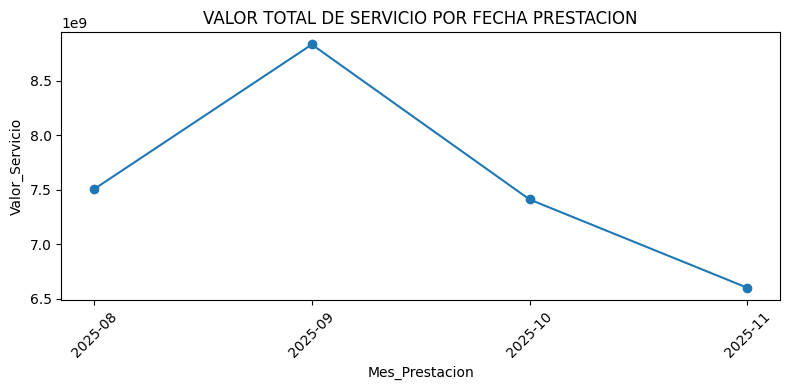

In [58]:
valor_mensual = (df_unificado.groupby('Fecha_Prestacion_Mes')['Valor_Servicio'].sum().reset_index())
plt.figure(figsize=(8,4))
plt.plot(
    valor_mensual['Fecha_Prestacion_Mes'].astype(str),
    valor_mensual['Valor_Servicio'],
    marker='o'
)
plt.title("VALOR TOTAL DE SERVICIO POR FECHA PRESTACION")
plt.xlabel("Mes_Prestacion")
plt.ylabel("Valor_Servicio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_final_AM.groupby(['fecha_dispensacion', 'id_documento_paciente'])['valor_total'].sum().groupby('fecha_dispensacion').mean()


,valor_total
fecha_dispensacion,
2025-08,39649.742018
2025-09,39989.429585
2025-10,36469.025821
2025-11,35532.195386


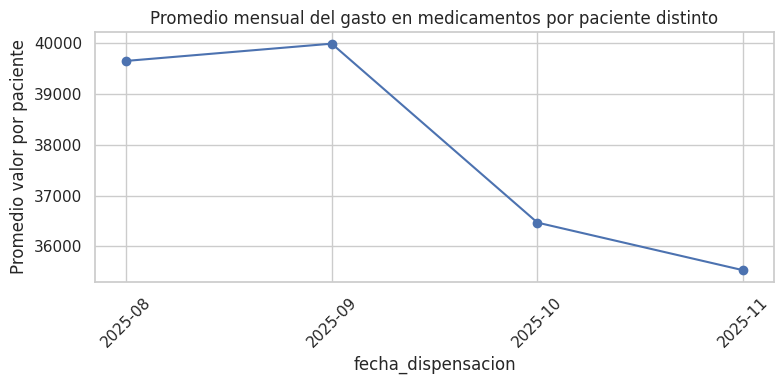

In [ ]:
indicadores_mensuales = (df_final_AM.groupby('fecha_dispensacion')
    .agg(
        gasto_total_mes=('valor_total', 'sum'),
        pacientes_distintos=('id_documento_paciente', 'nunique')
    )
    .reset_index()
)

indicadores_mensuales['promedio_valor_paciente'] = (
    indicadores_mensuales['gasto_total_mes'] /
    indicadores_mensuales['pacientes_distintos']
)
plt.figure(figsize=(8,4))
plt.plot(
    indicadores_mensuales['fecha_dispensacion'].astype(str),
    indicadores_mensuales['promedio_valor_paciente'],
    marker='o'
)
plt.title("Promedio mensual del gasto en medicamentos por paciente distinto")
plt.xlabel("fecha_dispensacion")
plt.ylabel("Promedio valor por paciente")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
top_medicamentos = df_final_AM['nombre_medicamento'].value_counts().head(10)
gasto_modalidad = df_final_AM.groupby('modalidad_contrato')['valor_total'].sum()
stats_cantidad = df_final_AM['cantidad_dispensado'].describe()

print("Top 10 Medicamentos:\n", top_medicamentos)
print("\nGasto por Modalidad:\n", gasto_modalidad)
print("\nEstadísticas de Cantidad:\n", stats_cantidad)

Top 10 Medicamentos:
 nombre_medicamento
LOSARTAN                   86953
HIDROCLOROTIAZIDA          59180
AMLODIPINO                 45597
ACETAMINOFEN               43465
METFORMINA                 31640
ACETIL SALICILICO ACIDO    29299
OMEPRAZOL                  26550
LEVOTIROXINA SODICA 50     24338
SALBUTAMOL (SULFATO)       17996
METOPROLOL TARTRATO        16324
Name: count, dtype: int64

Gasto por Modalidad:
 modalidad_contrato
CAPITA    8611227527
Name: valor_total, dtype: Int64

Estadísticas de Cantidad:
 count      765416.0
mean      50.199957
std      694.563975
min             1.0
25%             5.0
50%            30.0
75%            30.0
max         98944.0
Name: cantidad_dispensado, dtype: Float64


In [ ]:
# Resumen estadístico
df_final_AM.describe()

,id_archivo,fecha_hora_creacion,fecha_hora_dispensación,concentracion_medicamento,unidad_medida,unidad_dispensacion,cantidad_dispensado,dias_tratamiento,valor_unitario_medicamento,valor_servicio,concepto_recaudo,valor_copago,concecutivo,codigo_estado_rips_cargas,tarifa,valor_total,ID_Anonimo
count,7.654160e+05,765416,765416,765416.0,765416.000000,765416.000000,765416.0,765416.0,765416.0,765416.0,765416.000000,765416.000000,765416.000000,765416.0,765416.000000,765416.0,765416.000000
mean,3.612926e+06,2025-10-27 15:59:57.391599360,2025-09-27 08:51:45.247865088,0.0,166.731860,51.987804,50.199957,1.0,0.0,0.0,4.243703,289.494069,8.874206,5.0,1325.476097,11250.388713,549906.021221
min,2.490180e+06,2025-09-05 11:10:37,2025-08-01 00:00:00,0.0,62.000000,1.000000,1.0,1.0,0.0,0.0,1.000000,0.000000,1.000000,5.0,0.000000,0.0,100000.000000
25%,2.589376e+06,2025-09-10 16:02:20,2025-08-29 00:00:00,0.0,168.000000,66.000000,5.0,1.0,0.0,0.0,5.000000,0.000000,1.000000,5.0,48.000000,984.0,324891.750000
50%,3.191454e+06,2025-10-07 11:28:20,2025-09-25 00:00:00,0.0,168.000000,66.000000,30.0,1.0,0.0,0.0,5.000000,0.000000,2.000000,5.0,87.000000,2768.0,549935.500000
75%,4.454252e+06,2025-12-05 09:46:12,2025-10-28 00:00:00,0.0,168.000000,66.000000,30.0,1.0,0.0,0.0,5.000000,0.000000,4.000000,5.0,525.000000,6077.0,774890.250000
max,4.518965e+06,2025-12-09 15:24:25,2025-11-30 00:00:00,0.0,176.000000,81.000000,98944.0,1.0,0.0,0.0,5.000000,249164.000000,2166.000000,5.0,202445.000000,9204480.0,999998.000000
std,8.190063e+05,NaN,NaN,0.0,9.532998,25.288647,694.563975,0.0,0.0,0.0,1.544553,1253.186341,70.273644,0.0,4112.435544,66515.041413,259782.338521
